--- RAPPORT D'EFFICACITÉ : TRACKER SOLAIRE vs INSTALLATION FIXE ---
Énergie totale captée (Installation Fixe à 30°) : 80.66 Unités Arbitraires
Énergie totale captée (Tracker Actif PID)       : 85.58 Unités Arbitraires
Amélioration de la production d'énergie         : +6.10%


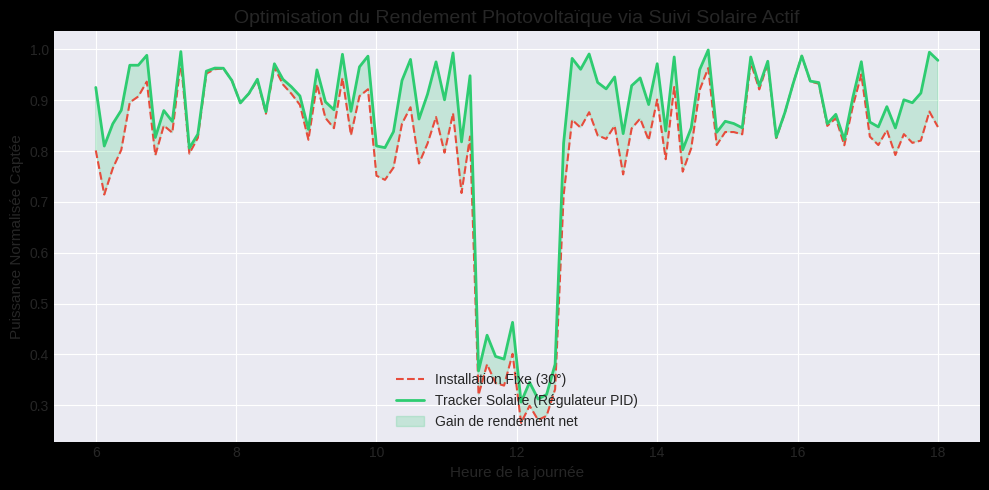

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. PARAMÈTRES DE LA SIMULATION ---
time_steps = 100
heures = np.linspace(6, 18, time_steps)  # Simulation de 6h00 à 18h00

# Modèle physique simplifié de l'élévation du soleil (ex: max 60° d'élévation en France)
sun_elevation = np.sin(np.pi * (heures - 6) / 12) * 60

# Simulation des conditions météorologiques (Couverture nuageuse diminuant l'irradiance)
np.random.seed(42)
cloud_cover = np.random.uniform(0.0, 0.2, size=time_steps)
cloud_cover[45:55] += 0.5  # Passage d'une grosse perturbation nuageuse vers midi
cloud_cover = np.clip(cloud_cover, 0, 1)

# --- 2. CONTRÔLEUR INDUSTRIEL PID ---
class PIDController:
    """ Régulateur PID standard pour l'asservissement du moteur du panneau """
    def __init__(self, kp, ki, kd):
        self.kp = kp  # Gain Proportionnel (Réactivité)
        self.ki = ki  # Gain Intégral (Correction des erreurs passées)
        self.kd = kd  # Gain Dérivé (Anticipation / Amortissement)
        self.previous_error = 0
        self.integral = 0

    def compute(self, setpoint, measured_value, dt=1):
        error = setpoint - measured_value
        self.integral += error * dt
        derivative = (error - self.previous_error) / dt
        output = (self.kp * error) + (self.ki * self.integral) + (self.kd * derivative)
        self.previous_error = error
        return output

# --- 3. BOUCLE DE SIMULATION ---
def simulate_solar_tracking():
    # Installation classique : Panneau fixe orienté à 30° (inclinaison standard)
    fixed_angle = 30.0
    power_fixed = []

    # Installation dynamique : Tracker Solaire Actif
    tracker_angle = 0.0
    power_tracked = []

    # Initialisation du régulateur PID pour le moteur
    pid = PIDController(kp=0.6, ki=0.1, kd=0.05)

    for i in range(time_steps):
        current_sun = sun_elevation[i]
        clouds = cloud_cover[i]

        # A. Calcul de rendement pour le système FIXE
        # La puissance captée dépend du cosinus de l'angle de désalignement
        misalignment_fixed = abs(current_sun - fixed_angle)
        efficiency_fixed = max(0, np.cos(np.radians(misalignment_fixed)))
        power_fixed.append(efficiency_fixed * (1 - clouds))

        # B. Calcul de rendement pour le TRACKER ACTIF
        # Le PID calcule l'instruction moteur pour rejoindre la position du soleil (setpoint)
        motor_adjustment = pid.compute(setpoint=current_sun, measured_value=tracker_angle)
        tracker_angle += motor_adjustment

        # Contraintes mécaniques du moteur (butées de 0° à 90°)
        tracker_angle = np.clip(tracker_angle, 0, 90)

        misalignment_tracked = abs(current_sun - tracker_angle)
        efficiency_tracked = max(0, np.cos(np.radians(misalignment_tracked)))
        power_tracked.append(efficiency_tracked * (1 - clouds))

    return np.array(power_fixed), np.array(power_tracked)

# --- 4. EXÉCUTION ET ANALYSE DES RÉSULTATS ---
print("--- RAPPORT D'EFFICACITÉ : TRACKER SOLAIRE vs INSTALLATION FIXE ---")
p_fixed, p_tracked = simulate_solar_tracking()

total_fixed = np.sum(p_fixed)
total_tracked = np.sum(p_tracked)
gain = ((total_tracked - total_fixed) / total_fixed) * 100

print(f"Énergie totale captée (Installation Fixe à 30°) : {total_fixed:.2f} Unités Arbitraires")
print(f"Énergie totale captée (Tracker Actif PID)       : {total_tracked:.2f} Unités Arbitraires")
print(f"Amélioration de la production d'énergie         : +{gain:.2f}%")

# --- 5. VISUALISATION (Matplotlib) ---
plt.figure(figsize=(10, 5))
plt.style.use('seaborn-v0_8-darkgrid') # Style graphique professionnel

plt.plot(heures, p_fixed, label="Installation Fixe (30°)", color='#e74c3c', linestyle='--')
plt.plot(heures, p_tracked, label="Tracker Solaire (Régulateur PID)", color='#2ecc71', lw=2)

plt.fill_between(heures, p_fixed, p_tracked, where=(p_tracked > p_fixed),
                 color='#2ecc71', alpha=0.2, label="Gain de rendement net")

plt.title("Optimisation du Rendement Photovoltaïque via Suivi Solaire Actif", fontsize=14)
plt.xlabel("Heure de la journée", fontsize=11)
plt.ylabel("Puissance Normalisée Captée", fontsize=11)
plt.xticks(np.arange(6, 19, 2))
plt.legend(loc="lower center", fontsize=10)
plt.tight_layout()
plt.show()